<a href="https://colab.research.google.com/github/lynnkaram/ml-course-projects/blob/main/project-1-regularization-and-kernels/regularization_kernels_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intermediate Machine Learning: Assignment 1

**Deadline**

Assignment 1 is due Wednesday, September 25 11:59 pm. Late work will not be accepted as per the course policies (see the syllabus on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or Copilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a .pdf on Gradescope. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each homework assignment are numbered. Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

To produce the .pdf, please do the following in order to preserve the cell structure of the notebook:

Go to "File" at the top-left of your Jupyter Notebook
Under "Download as", select "HTML (.html)"
After the .html has downloaded, open it and then select "File" and "Print" (note you will not actually be printing)
From the print window, select the option to save as a .pdf

**Topics**

 * Lasso
 * Bias-variance decomposition
 * Mercer kernels
 * LOOCV for kernel smoothing and ridge regression

This assignment will also help to solidify your Python and Jupyter notebook skills.


### Problem 1: Roping variables with the lasso (15 points)

In this exercise, we'll employ the lasso regression technique to identify key predictor variables from the diabetes dataset. This dataset is used in the study by Efron, Hastie, Johnstone, and Tibshirani (2004, *Annals of Statistics*, "Least Angle Regression"). The primary goal is to predict a quantitative measure of diabetes progression one year after baseline, based on ten standardized physiological and biochemical measurements.


The *Diabetes* dataset in the `sklearn.datasets` package is a classic benchmark for regression. It contains 442 samples with 10 features that have been centered to mean zero but not scaled to unit variance. The predictors include age, sex, body mass index (BMI), blood pressure (BP), and six blood serum measures (s1–s6: cholesterol, LDL, HDL, cholesterol/HDL ratio, triglycerides, and blood sugar). The target is a quantitative measure of diabetes progression one year after baseline. You can find details at https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset.

**Your tasks are as follows**:

1. **Plotting Lasso Paths**: Generate a visualization of the lasso regularization paths.
2. **Identifying Key Predictors**: Determine which coefficients of \( \beta \) are non-zero.
3. **Estimating Coefficients**: Provide the best estimate for these non-zero coefficients.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import Lasso
from sklearn.datasets import load_diabetes
%matplotlib inline

Just run the next cell to read in the data.

In [ ]:
# Insert this code just above problem 1.1
X, y = load_diabetes(return_X_y=True)
n, p = X.shape
print("Number of rows: {}".format(n))
print("Number of columns: {}".format(p))
# Note that X, y = load_diabetes(return_X_y=True) has already been standardized.
# You can explore the raw data with the following code:
X_raw, y_raw = load_diabetes(return_X_y=True, scaled=False)
print(np.allclose(y, y_raw))
print(np.allclose(X/np.std(X,axis=0), (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)))
# The above two print statements should both return True.

Number of rows: 442
Number of columns: 10
True
True


### 1.1: Lasso regularization paths

Run the lasso and plot the regularization paths. You can use the `Lasso` class from the `sklearn.linear_model` package. Plot the parameter paths with the regularization level $\lambda$ (`alpha` in the code) on the log-scale, as done in the lasso demo code from class. (As always, be sure to label your axes.)

Show two plots, one where you run the lasso on the variables as given in the dataset, another where you standardize the variables to have mean zero and standard deviation one. Describe the differences in the regularization paths, and explain those differences.

When the predictors are standardized, what order do they appear in the lasso fits? That is, as $\lambda$ decreases from infinity to zero, what is the sequence of variables that enter the model with nonzero coefficients? Explain why this ordering may (or may not) make sense.


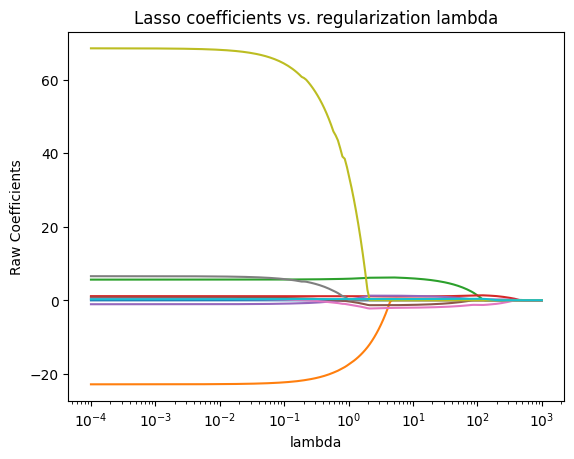

In [ ]:
# First run lasso on the variables as given in the dataset (i.e raw data)
# Reference: Code taken from lasso demo

# alphas = np.linspace(0.01,1000,10000) --> based on the demo code, this would work (this is a linear space)
#                                           but here we are asked to plot with log-scale. So I changed this part of the code.
alphas = np.logspace(-4, 3, 200)   # log-scale
lasso = Lasso()
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_raw, y_raw) #raw coefficients (as given in dataset)
    coefs.append(lasso.coef_)

plt.figure()
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('lambda')
plt.ylabel('Raw Coefficients')
plt.title('Lasso coefficients vs. regularization lambda');


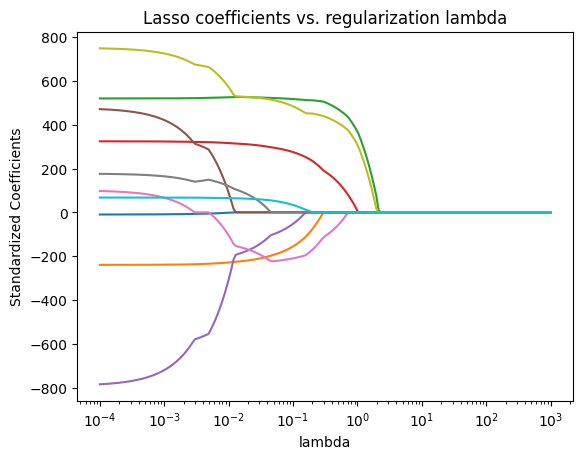

In [ ]:
# Since X, y = load_diabetes(return_X_y=True) has already been standardized,
# we can run the lasso again on X, y to compare it with the raw data
# Reference: code from lasso demo

# alphas = np.linspace(0.01,10,10000) --> would work if we use linear scale
alphas = np.logspace(-4, 3, 200)   # log-scale
lasso = Lasso()
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X, y) #standardized coefficients
    coefs.append(lasso.coef_)

plt.figure()
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('lambda')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients vs. regularization lambda');



**The differences between the raw vs standardized data:**

In both cases, we see that as lambda becomes very large, the coefficients shrink to 0 and as lambda is getting smaller, the curves are further away from 0.

In the raw data (not standardized), the features are on different numerical scales (e.g. BME vs serum measures). The lasso penalises coefficients by magnitude, this means larger-scale features can appear to dominate. In other words, in the raw path plot, curves differ widely in height and the points where they hit zero are influenced by unit scales. In fact, we can see that we need a much larger linear space for this to shrinking phenomenon be visible (i.e. stop value is 1000), and that even with this large linear space, we don't see really see lines touching 0 at a single point.

In the standardized data, each column has a mean of 0 and standard deviation of 1, so the penalty is applied fairly to all predictors. Coefficients are directly comparable and the path shapes primarily reflect predictive strengths as a condition of lambda. We use a much smaller linear space (i.e. stop value is 100), and we can see the shrinkage phenomenon happening (i.e we can see where the coefficients are equal to 0).

The next step (below) is to look at the entry order of the standardized data.

In [ ]:
# "When the predictors are standardized, what order do they appear in the lasso fits? That is, as  𝜆  decreases from infinity to zero,
# what is the sequence of variables that enter the model with nonzero coefficients? Explain why this ordering may (or may not) make sense".
# I acknowlegde the use of ChatGPT for certain lines of this code
from sklearn.linear_model import lasso_path

names = load_diabetes().feature_names
alphas, coefs, _ = lasso_path(X, y)
entered = (coefs != 0)    #looks at non zero coeffs (so the ones that weren't shrinked)
enter_idx = np.where(entered.any(axis=1), entered.argmax(axis=1), np.inf)
order = np.argsort(enter_idx)  #sort them in order of entries

print([names[i] for i in order if np.isfinite(enter_idx[i])])

['bmi', 's5', 'bp', 's3', 'sex', 's6', 's1', 's4', 's2', 'age']


**What is the sequence of variables that enter the model with nonzero coefficients?**

Following the logic that the largest lambda at which each coefficient is non-zero comes first in the sequence, we get:

[bmi -> s5 -> bp -> s3 -> sex -> s6 -> s1 -> s4 -> s2 -> age]

**Explain why this ordering may (or may not) make sense**

This order makes sense. It indicates that BMI (body mass index) and s5 (ltg, log of serum triglycerides level) enter first, which means that they have the strongest association with diabetes. This can be factually checked online. After that comes blood pressure and s3 (hdl, high-density lipoproteins) measures. Demographic variables like age enter last because they contribute the least compared to the other variables. We can also note that because several predictors are correlated, there could be a potential swap of variables in the middle of the entries.

### 1.2: Select, estimate, and predict

The true model is linear, and only a subset $S \subset \{0,1,\ldots, 9\}$ of the 10 variables have non-zero coefficients $\beta_j$. In this problem you should make three estimates:

1. An estimate $\hat S$ of $S$
2. An estimate $\hat \beta_j$ for each $j\in \hat S$
3. An estimate of the predictive risk ${\mathbb E}(Y - X\hat\beta)^2$


We are not specifying how you should construct these estimates. You should use your judgement, taste, and
the tools provided from class. However, you must clearly explain and justify whatever approach that you use.


**Before we start**

For this part, I am referring to the following slide to justify my approach. By following the steps that were covered in the lecture as much as possible, I have written which steps are more or less done in each cell below.  



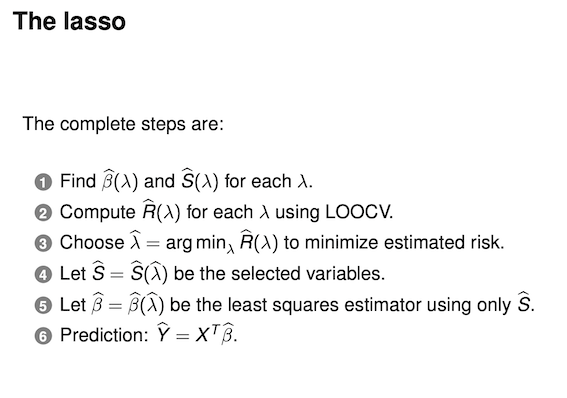

In [ ]:
# I acknowledge the use of ChatGPT for this exercise as a helping tool to work with sklearn, check certain lines and debug code where needed.

In [ ]:
# 1. An estimate S^ of S.
# We can use cross validation for this, and we can import the LassoCV package to compute it.
# For steps (1) to (4)
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=10, random_state=0)  # cross-validation picks alpha. take 10 fold because that was the example discussed in class
                                        # and 10 is a standard cv value. we could also take cv = 5.
lasso.fit(X, y)
S_hat = np.where(lasso.coef_ != 0)[0]   # array of 10 nb, one for each variable. take indices of selected variables (i.e when coeff is != 0)
print("S^:", [names[i] for i in S_hat])
print("Alpha value:", lasso.alpha_)

S^: ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']
Alpha value: 0.05705392298201018


**Brief explanation**

We get 7 variables in the subset : sex, bmi, s1, s3, s5 and s6, for a chosen alpha value of 0.056 (which is the estimated lasso value that balances bias and variances the best).  

In [ ]:
# 2. An estimate of 𝛽j^ for each j in S^
# This is step (5)
from sklearn.linear_model import LinearRegression
ols = LinearRegression().fit(X[:, S_hat], y)

# print each selected variable with its OLS coefficient
selected_names = [names[i] for i in S_hat]
for name, coef in zip(selected_names, ols.coef_):
    print(f"{name}: {coef}")
print("Intercept:", float(ols.intercept_))

sex: -232.74310799247746
bmi: 526.4395507602541
bp: 315.35955074102174
s1: -146.3464901605258
s3: -235.2967329275092
s5: 540.1842336154455
s6: 72.18267214903256
Intercept: 152.13348416289602


**Brief explanation**

These results make sense because a positive β means that a higher value of that feature increases the prediction. The opposite is true for negative values. So here, BMI is positive, and but also very large, which aligns with what was said in 1.1 because it means it has the strongest association with diabetes prediction. On the other hand, sex has a very negative value, which makes sense as it was the last one on the list of entries.

In [ ]:
# 3. An estimate of the predictive risk E
# This is step (6) + estimation of risk
from sklearn.model_selection import cross_val_score

E_hat_cv = -cross_val_score(LinearRegression(), X[:, S_hat], y, scoring="neg_mean_squared_error", cv=10).mean()
print("Predictive risk E^:", float(E_hat_cv))

Predictive risk E^: 2965.423419132446


### Problem 2: Risky business (10 points)

In class [(and in these notes)](https://github.com/YData123/sds365-fa22/raw/main/notes/kernel-bias-variance.pdf) we sketched a proof that, when the regression function has two bounded derivatives,
 the bias and variance for kernel smoothing scale as

$$ \mbox{bias}^2 = O\left(h^4\right)$$
$$ \mbox{var} = O\left(\frac{1}{nh^p}\right).$$

Here $h$ is the bandwidth parameter, $n$ is the sample size, and $p$ is the number of predictor variables. These expressions are asymptotic, meaning that they apply as $n$ gets large and $h$ gets small.  In this problem your job is to reason about the implications of this bias-variance decomposition for prediction.

*Note:* For this problem, you may either enter your answers in Markdown using $\rm\LaTeX$, or you write them on paper and scan to insert as an image in the notebook; whichever you prefer.


### 2.1 Selecting the optimal bandwidth

Suppose that the bias and variance are such that

$$ \mbox{bias}^2(\hat m(x))  \leq c_1 h^4 $$
$$ \mbox{var}(\hat m(x)) \leq c_2 \frac{1}{nh^p}.$$

for two constants $c_1$ and $c_2$. Using these expressions and a little calculus, determine the optimal bandwidth $h$ to minimize the risk function

$$R(h) = {\mathbb E}\left(\hat m(x) - m(x)\right)^2.$$

Your answer should involve the constants $c_1, c_2$, and $n$ and $p$. Give a bound on the resulting risk using this bandwidth.


### 2.2 Bandwith selection without tears

Now, going back to the expressions $\mbox{bias}^2 = O\left(h^4\right)$ and $ \mbox{var} = O\left(\displaystyle\frac{1}{nh^p}\right)$, explain why the scaling of the optimal bandwidth (as a function of $n$ and $p$), must satisfy
$\mbox{bias}^2  \approx \mbox{var}$; that is, they must be of the same order as $h\to 0$. Then, without using any calculus, use this argument to determine the optimal scaling of the bandwidth and the fastest rate at which the
risk $R(h) = {\mathbb E}\left(\hat m(x) - m(x)\right)^2$ can approach zero as the sample size increases.


### 2.3 The cursed COD

Using the risk bound you derive above, make a plot that demonstrates the curse of dimensionality by plotting the sample size required to achieve a given level of risk. Specifically, let the target risk $R$ vary between 0.1 and 0.5, and let the dimension $p$ vary between 1 and 20, and plot the sample size required to achieve that risk. Give a single plot that shows the collection of curves for each dimension.




**Please refer to Markdown (attached as pdf) for parts 2.1 and 2.2**

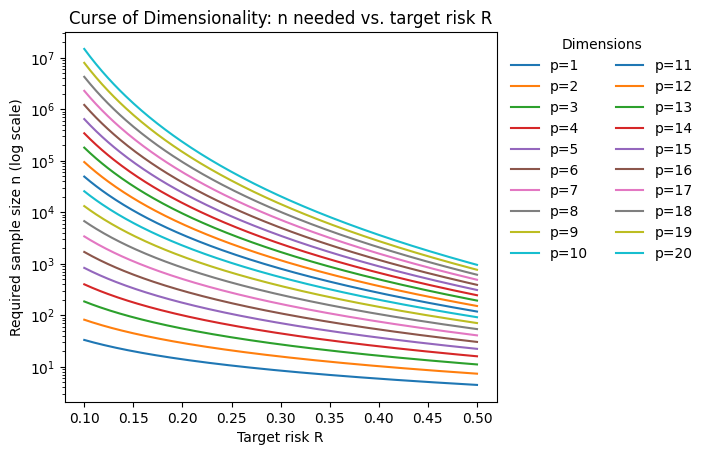

In [ ]:
# Solution to 2.3
# Please refer to the small markdown (pdf) that I wrote for this section too,
# just to provide a little more explanation on how I defined things.
# First, set arbitrary constants, target risk range and dimensions
c1 = 1
c2 = 1
R = np.linspace(0.1, 0.5, 200) # risk R varying between 0.1 and 0.5
ps = range(1, 21)              # p varying between 1 and 20 so p = 1, 2, ..., 20

# plot
plt.figure()
for p in ps:
    K_p = c1 * (1 + 4/p) * ((p * c2) / (4 * c1)) ** (4 / (p + 4)) #define it like in my markdown
    n_required = (K_p / R) ** ((p + 4) / 4)   # n >= (K_p / R)^{(p+4)/4}
    plt.plot(R, n_required, label=f"p={p}")
plt.yscale("log")
plt.xlabel("Target risk R")
plt.ylabel("Required sample size n (log scale)")
plt.title("Curse of Dimensionality: n needed vs. target risk R")
plt.legend(title="Dimensions", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0., ncol=2, frameon=False) #just formatting
plt.gcf().subplots_adjust(right=0.8)

### Problem 3: A kernel of truth (15 points)

For problem you will implement nonparametric regression using Mercer kernels and penalization, in 1-dimension. This can be compared to regression using smoothing kernels.

As discussed in lecture, nonparametric regression with Mercer kernels is based on the infinite dimensional ridge regression

$$ \hat m = \mbox{argmin} \| Y - m \|^2 + \lambda \|m\|_K^2$$

By the representer theorem, this is equivalent to setting $\hat m(x) = \sum_{i=1}^n \hat \alpha_i K(X_i, x)$ and
using the finite dimensional optimization

$$ \hat \alpha = \mbox{argmin} \| Y - {\mathbb K} \alpha \|^2 + \lambda \alpha^T {\mathbb K} \alpha$$

###  3.1 Solve

Derive a closed-form expression for the minimizer $\hat\alpha$. Show all of the steps in your derivation,
and justify each step. (As above, you may either enter your answers in Markdown using $\rm\LaTeX$, or insert an image of your handwritten solution.)


**Please refer to Markdown (attached as pdf)**

###  3.2 Implement

Next you will use your solution above and implement Mercer kernel regression. We give some starter code.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output
from time import sleep

The following cell defines some "helper functions" for this exercise. You don't need to change any of this code.
(If you do want to make changes, just describe what you did and why.)

In [ ]:
def plot_estimate(x, f, fhat, X, y, sigma, lmbda, sleeptime=.01):
    clear_output(wait=True)
    plt.figure(figsize=(10,6))
    plt.plot(x, f, color='red', linewidth=2, label='true function')
    plt.plot(x, fhat, color='blue', linewidth=2, label='estimated function')
    plt.scatter(X, y, color='black', alpha=.5, label='random sample')
    plt.ylim(np.min(f)-4*sigma, np.max(f)+4*sigma)
    plt.legend(loc='upper left')
    plt.title('lambda: %.3g' % lmbda)
    plt.xlabel('x')
    plt.ylabel('estimated m(x)')
    plt.show()
    sleep(sleeptime)

def true_fn(x):
    return 3*x**2

def run_simulation(kernel, lmbdas, show_bias_variance=True):
    min_x, max_x = -1, 1
    x = np.linspace(min_x, max_x, 100)
    f = true_fn(x)
    sigma = .25
    estimates = []
    trials = 500

    for lmbda in lmbdas:
        estimates_lambda = []
        for i in np.arange(trials):
            X = np.sort(np.random.uniform(low=min_x, high=max_x, size=50))
            fX = true_fn(X)
            y = fX + sigma*np.random.normal(size=len(X))
            fhat = mercer_kernel_regress(kernel, X, y, x, lmbda=lmbda)
            if i % 50 == 0:
                plot_estimate(x, f, fhat, X, y, sigma, lmbda)
            estimates_lambda.append(fhat)
        estimates.append(estimates_lambda)

    if show_bias_variance == False:
        return

    fhat = np.array(estimates)
    sq_bias = np.zeros(len(lmbdas))
    variance = np.zeros(len(lmbdas))

    for i in np.arange(len(lmbdas)):
        sq_bias[i] = np.mean((np.mean(fhat[i], axis=0) - f)**2)
        variance[i] = np.mean(np.var(fhat[i], axis=0))

    plt.figure(figsize=(10,6))
    plt.plot(lmbdas, sq_bias, label='squared bias', linewidth=2)
    plt.plot(lmbdas, variance, label='variance', linewidth=2)
    plt.plot(lmbdas, sq_bias + variance, label='risk')
    plt.legend()
    plt.show()


Your job is to implement Mercer kernel regression and run it on two
different kernel functions. The two kernels could simply be the Gaussian kernel
with two different bandwidths, or you might experiment with other kernels.

The function `mercer_kernel_regress` takes a kernel, training data `X` and `y`, an array of values `x` to evaluate the function on, and a regularization parameter. You'll use your derivation above to
determine the coefficients $\alpha$. For some clues and suggestions on how to do the
implementation, see our demo code for smoothing kernels. You need to do something very similar.


In [ ]:
def mercer_kernel_regress(kernel, X, y, x, lmbda):
    # your implementation here
    n = len(X)
    m = len(x)
    K = kernel(X, X) # kernel matrix K (n x n) for training data
    alpha = np.linalg.solve(K + lmbda * np.eye(n), y) # solve for alpha: (K + lambda*I) * alpha = y

    # now compute kernel matrix between evaluation points and training points
    K_eval = kernel(x, X)  # (m x n)
    fhat = K_eval @ alpha  # make predictions: f(x) = sum_i alpha_i * K(x_i, X_j)
    return fhat

def kernel1(x,y):
    # your implementation here
    h = 0.1 # experimented with 0.01, 0.05 and 0.1.
    x = np.array(x).reshape(-1, 1)  # column vector
    y = np.array(y).reshape(1, -1)  # row vector
    K = (1/h) * np.exp(-(x - y)**2 / (2*h**2))
    return K

def kernel2(x,y):
    # your implementation here
    h = 0.3
    x = np.array(x).reshape(-1, 1)
    y = np.array(y).reshape(1, -1)
    K = (1/h) * np.exp(-(x - y)**2 / (2*h**2))
    return K

###  3.3 Run two simulations and select regularization parameters

Finally, using our starter code and your own implementation above, run two simulations, one
using `kernel1` and the other using `kernel2`. After each simulation, select a regularization level from the bias-variance tradeoff, and then run a final simulation with that regularization level. In the following
starter code, you only need to specify the sequence of regularization parameters.


In [ ]:
# I acknowledge the use of Claude to help me define the smoothing demo as a function

# First we define a simulation function so we can run it twice.
# I used the smoothing demo from lectures as a template to write this code.
def run_kernel_simulation(kernel, kernel_name, h_value):
    print(f"Testing with {kernel_name} (h={h_value})")

    min_x, max_x = -1, 1
    x = np.linspace(min_x, max_x, 100)
    f = true_fn(x)
    sigma = .25
    estimates = []
    lambdas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
    trials = 500

    for lmbda in lambdas:
        estimates_lambda = []
        for i in np.arange(trials):
            X = np.sort(np.random.uniform(low=min_x, high=max_x, size=50))
            fX = true_fn(X)
            y = fX + sigma*np.random.normal(size=len(X))
            fhat = mercer_kernel_regress(kernel, X, y, x, lmbda)
            if i % 50 == 0:
                plot_estimate(x, f, fhat, X, y, sigma, lmbda)
            estimates_lambda.append(fhat)
        estimates.append(estimates_lambda)

    # Compute bias-variance decomposition
    fhat = np.array(estimates)
    sq_bias = np.zeros(len(lambdas))
    variance = np.zeros(len(lambdas))

    for i in np.arange(len(lambdas)):
        sq_bias[i] = np.mean((np.mean(fhat[i], axis=0) - f)**2)
        variance[i] = np.mean(np.var(fhat[i], axis=0))

    plt.figure(figsize=(10,6))
    plt.plot(lambdas, sq_bias, label='squared bias', linewidth=2)
    plt.plot(lambdas, variance, label='variance', linewidth=2)
    plt.plot(lambdas, sq_bias + variance + sigma**2, label='risk', linewidth=2)
    plt.xlabel('regularization parameter lambda')
    plt.legend(loc='upper right')
    plt.title(f'Bias-Variance Tradeoff - {kernel_name} (h={h_value})')
    plt.show()

    # Find optimal lambda
    risk = sq_bias + variance + sigma**2
    optimal_idx = np.argmin(risk)
    optimal_lambda = lambdas[optimal_idx]
    print(f"Optimal lambda for {kernel_name}: {optimal_lambda:.3f}")
    return optimal_lambda

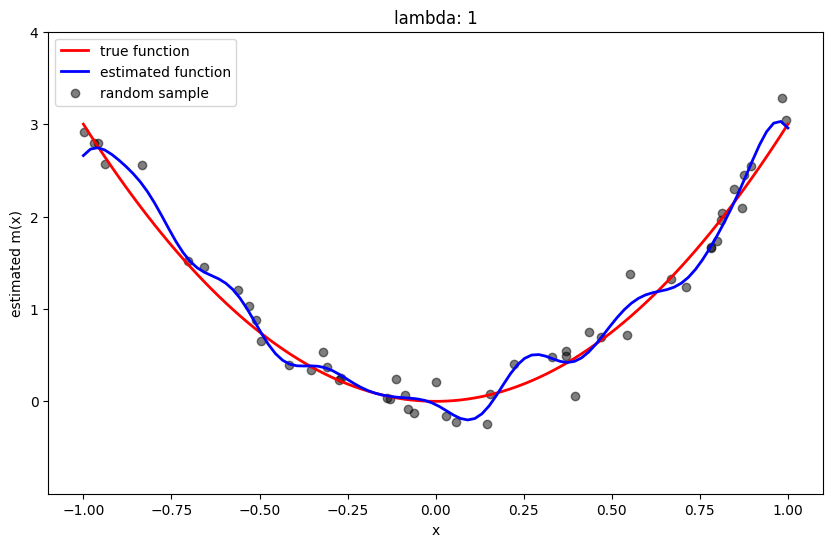

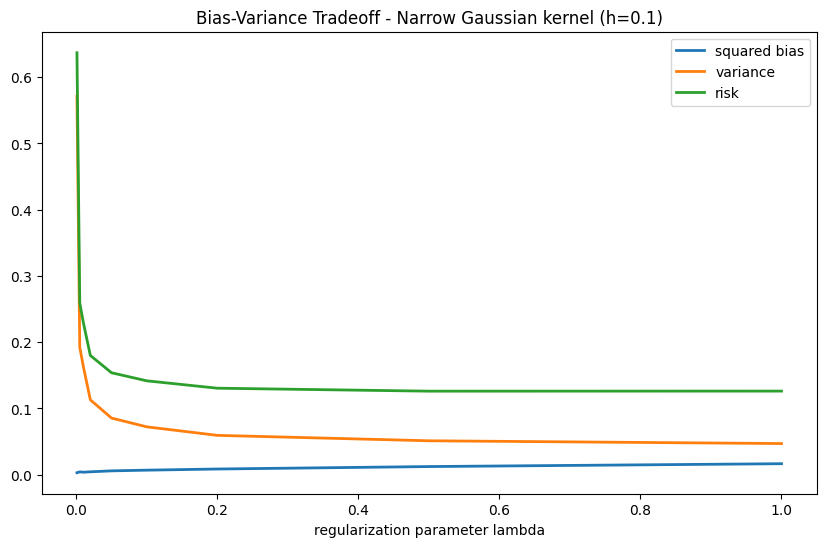

Optimal lambda for Narrow Gaussian kernel: 0.500


In [ ]:
# Simulation 1: run the narrow kernel
optimal_lambda1 = run_kernel_simulation(kernel1, "Narrow Gaussian kernel", 0.1)

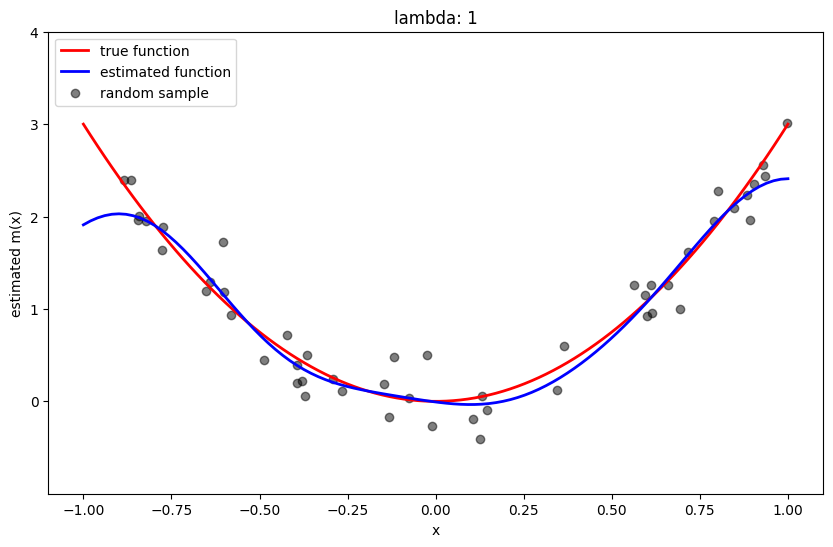

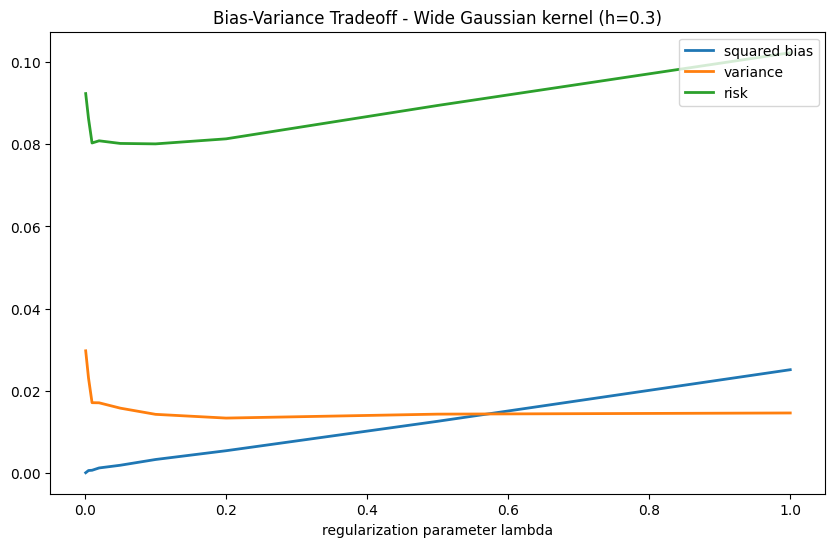

Optimal lambda for Wide Gaussian kernel: 0.100


In [ ]:
#Simulation 2: run the wide kernel
optimal_lambda2 = run_kernel_simulation(kernel2, "Wide Gaussian kernel", 0.3)

**Note**: In both graphs, we can see the usual bias-variance tradeo-off curve, where bias increases, variance decreases, and risk is the sum of both curves.

### Problem 4: An algebraic simplification of LOOCV (15 points)

Leave-One-Out Cross Validation (LOOCV) is a specific type of
$K$-fold cross validation where $K$ equals the number of observations in the dataset.
It works as follows for a training set with $n$ observations:

1. A single observation is used as the validation set,
    and the remaining $n-1$ observations serve as the training set.
2. A model is trained on the $n-1$ observations and
    validated on the single left-out observation.
3. This process is repeated $n$ times, each time leaving out a different
    observation as the validation set.
4. The LOOCV error is then the average error across all $n$ trials.

LOOCV is particularly useful because:
- It utilizes almost all the data for training,
    so it's less prone to high variance compared to other validation schemes.
- Since each observation is tested exactly once,
    LOOCV provides a very thorough out-of-sample testing mechanism.

However, it can be computationally expensive because you have to fit the model $n$ times.
    Luckily, for some models, there are algebraic simplifications available
    that make it computationally efficient.
    Expressing LOOCV in terms of the hat matrix allows for efficient
    computation of the LOOCV error without the need to refit the model for
    each left-out observation, making it a valuable tool for model evaluation.

Recall that the LOOCV error can be expressed as:

$$ LOOCV = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_{-i} \right)^2, $$

where $\hat{y}_{-i}$ represents the prediction for the $i^{th}$ observation
when it's left out from the training process.
In the following questions, you will be deriving an alternative expression
of the LOOCV error for both kernel and ridge regression, following the hints below.

### 1. LOOCV for kernel smoothing:

For kernels, we know that the LOOCV error can be equivalently written as the following form:

$$ LOOCV = \frac{1}{n} \sum_{i=1}^{n} \left( \frac{y_i - \hat y_i}{1 - L_{ii}} \right)^2, $$
where $\hat y_i$ is the predicted value from the model fit on all data, and
$L_{ii}$ is the $i^{th}$ diagonal element of the hat matrix $L$.

For kernel regression, we have
$$ \hat{y} = L y, $$
where
- $ \hat{y} $ is the vector of predictions.
- $ y $ is the observed response values.
- $ L $ is the hat matrix and is defined by the kernel (for a given bandwidth).
So, each diagonal element $ L_{ii} $ of the matrix $ L $ is defined as:
$$ L_{ii} = \frac{K\left(x_i, x_i\right)}{\sum_{j=1}^{n} K\left(x_i, x_j\right)}, $$
where
- $ K $ is the kernel function.
- $ x_i $ and $ x_j $ are the predictor values for observations $ i $ and $ j $, respectively.

The diagonal elements $ L_{ii} $ give the "leverage" of each observation, which can be interpreted as the influence an observation has on its own prediction.

Derive this alternative expression of the LOOCV error for kernel regression. That's to say, for kernel regression, prove that

$$ y_i - \hat{y}_{-i}  =  \frac{y_i - \hat y_i}{1 - L_{ii}}$$

**Please refer to Markdown (attached as pdf)**

## Problem 5: LASSO and Elastic Net

In class, we derived the solution for the one-dimensional LASSO using convexity and subgradients. We also know that coordinate descent can be used to solve LASSO in the high-dimensional case. Sometimes, we introduce a penalty that is a mixture of the $\ell_1$ and $\ell_2$ norms,  

$$
\lambda_1 \|\beta\|_1 + \lambda_2 \|\beta\|_2^2,
$$  

which is referred to as the **Elastic Net**. This problem demonstrates how the Elastic Net can be computed using the LASSO.

Let us first recall the one-dimensional LASSO objective:

$$
f(\beta) = \frac{a}{2}\beta^2 - b\beta + \lambda |\beta|,
\qquad a > 0,\; \lambda \ge 0.
$$

The minimizer is given by

$$
\widehat{\beta} = \frac{\operatorname{sign}(b)\,\big(|b| - \lambda\big)_+}{a},
$$

where $(x)_+ = \max\{x,0\}$.

5.1 Solve the one-dimensional LASSO problem

$$
\widehat{\beta} = \arg\min_\beta \left\{ \frac{1}{2n}\sum_{i=1}^n (y_i - \beta x_i)^2 + \lambda |\beta| \right\},
$$

where $\lambda \geq 0$ and at least one $x_i \neq 0$.

**Please refer to Markdown (attached as pdf)**

5.2 Solve the one-dimensional Elastic Net
$$
\widehat{\beta} = \arg\min_\beta \left\{ \frac{1}{2n} \sum_{i=1}^n (y_i - \beta x_i)^2 + \lambda_1 |\beta| + \lambda_2 \beta^2 \right\},
$$

where $\lambda_1 \geq 0$, $\lambda_2 \geq 0$, and at least one $x_i \neq 0$.  

*Hint:* Convert this problem into the form of 5.1. What happens if we observe a new data point $(\sqrt{2n\lambda_2}, 0)$?

**Please refer to Markdown (attached as pdf)**

5.3 Now consider the case where we have data $\mathbf{Y} \in \mathbb{R}^n$ and $\mathbf{X} \in \mathbb{R}^{n \times p}$. We want to find an estimator

$$
\widehat{\beta} = \arg\min_\beta \left\{ \frac{1}{2n}\| \mathbf{Y} - \mathbf{X}\beta\|_2^2 + \lambda_1 \|\beta\|_1 + \lambda_2 \|\beta\|_2^2 \right\}.
$$

Assume we have access to an oracle that can solve the LASSO. How can we use it to solve the Elastic Net?  

*Hint:* Construct augmented variables $\mathbf{Y}^*$ and $\mathbf{X}^*$
(not necessarily the same shapes as $\mathbf{Y}$ and $\mathbf{X}$) and show that the objective is equivalent to
$$
\frac{1}{2\,\mathrm{len}(\mathbf{Y}^*)}
\|\mathbf{Y}^* - \mathbf{X}^*\beta\|_2^2
+ \lambda_1 \|\beta\|_1.
$$

**Please refer to Markdown (attached as pdf)**

5.4 Now revisit the diabetes dataset from the first problem. Apply the result you derived, together with the `Lasso` implementation from `sklearn.linear_model`, to solve the elastic net. Specifically, we want to solve

$$
\widehat{\beta} = \arg\min_\beta \left\{ \frac{1}{2n}\|\mathbf{Y} - \mathbf{X}\beta\|_2^2
+ \lambda_1 \|\beta\|_1
+ \lambda_2 \|\beta\|_2^2 \right\},
$$
where $\lambda_1 = \lambda_2 = 0.1$.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
%matplotlib inline
X, y = load_diabetes(return_X_y=True)
X = np.hstack([np.ones((X.shape[0], 1)), X])
n, p = X.shape
n, p = X.shape
m = n + p # define m
scale = np.sqrt(m / n)

lambda1,lambda2 = 0.1, 0.1
y_star = np.concatenate([scale * y, np.zeros(p)])
X_scaled = scale * X
X_identity = np.sqrt(2 * m * lambda2) * np.eye(p)
X_star = np.vstack([X_scaled, X_identity])
model = Lasso(alpha=lambda1, fit_intercept=False)
model.fit(X_star, y_star)
your_coef = model.coef_

# You can use the following code to verify your answer
from sklearn.linear_model import ElasticNet
lambda1, lambda2 = 0.1, 0.1
alpha = lambda1 + 2 * lambda2
l1_ratio = lambda1 / (lambda1 + 2 * lambda2)

# Fit ElasticNet with your X, y
model = ElasticNet(alpha=alpha,
                   l1_ratio=l1_ratio,
                   fit_intercept=False,
                   max_iter=10000,
                   tol=1e-6,
                   selection='cyclic')

model.fit(X, y)
elastic_coef = model.coef_
print(np.linalg.norm(your_coef - elastic_coef)/np.linalg.norm(elastic_coef))  # should be a very small number

2.473299603237532e-07


**Brief Explanation**

Fitting Lasso on the augmented (X\*, Y\*) reproduces the Elastic Net solution, and the very small number (i.e. the relative difference) of 2.47e-7 confirms that they match.

5.5 Which values of $\lambda_1$ and $\lambda_2$ are appropriate? A common approach is to use cross-validation. For simplicity, split the data once into training and validation sets, fit the model with different $(\lambda_1,\lambda_2)$, and compare the mean squared error (MSE) on the validation set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=365)
scalerX, scalery = StandardScaler(), StandardScaler()
X_train = scalerX.fit_transform(X_train)
X_test = scalerX.transform(X_test)
y_train = scalery.fit_transform(y_train.reshape(-1,1)).ravel()
y_test = scalery.transform(y_test.reshape(-1,1)).ravel()
grid = np.linspace(0.001, 1.0, 30)
params = []
mses = []
for lambda1 in grid:
    for lambda2 in grid:
        # fit a elastic net with lambda1 and lambda2 on (X_train, y_train)
        n_tr, p_tr = X_train.shape
        m_tr = n_tr + p_tr
        scale = np.sqrt(m_tr / n_tr)

        y_star = np.concatenate([scale * y_train, np.zeros(p_tr)])
        X_star = np.vstack([scale * X_train, np.sqrt(2 * m_tr * lambda2) * np.eye(p_tr)])
        model = Lasso(alpha=lambda1, fit_intercept=False, max_iter=100000, tol=1e-6)  # fit LASSO on (X_star, y_star)
        model.fit(X_star, y_star)
        y_pred = X_test @ model.coef_  # validate on the original test split
        mse = mean_squared_error(y_test, y_pred) # compute the mse on (X_test, y_test)

        # you should use Lasso from sklearn. don't use ElasticNet.
        params.append((lambda1, lambda2))
        mses.append(mse)
your_lambda1,your_lambda2 = params[np.argmin(mses)]

#You can verify your answer using the following code
params2 = []
mses2 = []


In [ ]:
for lambda1 in grid:
    for lambda2 in grid:
        alpha = lambda1 + 2 * lambda2
        l1_ratio = lambda1 / (lambda1 + 2 * lambda2)
        model = ElasticNet(alpha=alpha,
                   l1_ratio=l1_ratio,
                   fit_intercept=False,
                   max_iter=10000,
                   tol=1e-6,
                   selection='cyclic')
        model.fit(X_train, y_train)
        mse = mean_squared_error(y_test, model.predict(X_test))
        params2.append((lambda1, lambda2))
        mses2.append(mse)
select_lambda1,select_lambda2 = params2[np.argmin(mses2)]

print(your_lambda1 == select_lambda1 and your_lambda2 == select_lambda2)   # should be True

True
